In [1]:
import numpy as np
import skimage
import skimage.io
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import pandas as pd
import shutil
from skimage import (
    data, restoration, util
)
import tifffile as tp

In [2]:
#file_list = pd.Series(glob.glob('/home/giuseppe/devices/Delta_Tissue/IMC/Img_Denoised/processed/*')).str.replace('Img_Denoised/non_preprocessed/','split_channels_nohpf')+'/Carboplatin.tiff'
file_list = glob.glob('/home/giuseppe/devices/Delta_Tissue/IMC/split_channels_nohpf/*/Carboplatin.tiff')
file_list = pd.DataFrame(file_list,columns = ['path'])
file_list['acquisition_ID'] = file_list.path.str.split('/').str[-2]
file_list['Leap_ID'] = file_list.acquisition_ID.str.split('_',n = 1).str[0].str.upper()
file_list['Leap_ID'] = file_list['Leap_ID'].str[:7]#leap_ID should be Leap123, anything more is stripped
biosamples_path = '~/devices/Delta_Tissue/IMC/IMC_data/ExtraDocs/processed_response.csv'
biosamples =pd.read_csv(biosamples_path)
file_list = file_list.merge(biosamples,left_on='Leap_ID',right_on= 'LEAP_ID').drop(['LEAP_ID'],axis = 1)#add metadata on patient

In [39]:
for file in file_list.path:
    acquisition_id = file.split('/')[-2]
    #shutil.copy2(file,'/home/giuseppe/devices/Delta_Tissue/IMC/Img_Denoised/'+acquisition_id+'/Carboplatin.tiff')
    

In [37]:
file_list[file_list['SAMPLE_TYPE_(CORE/RESECTION)']=='CORE'].path.str.lstrip('/home/giuseppe/devices/Delta_Tissue/IMC/split_channels_nohpf')

1       Leap086_4/Carboplatin.tiff
2       Leap009_4/Carboplatin.tiff
3       Leap043_1/Carboplatin.tiff
4       Leap073_9/Carboplatin.tiff
5      Leap017_14/Carboplatin.tiff
                  ...             
693     Leap095_6/Carboplatin.tiff
694     Leap013_7/Carboplatin.tiff
695    Leap066_14/Carboplatin.tiff
699    Leap088a_4/Carboplatin.tiff
701    Leap017_15/Carboplatin.tiff
Name: path, Length: 453, dtype: object

In [3]:
#getting the 95% of core images. Also saving Carboplatin to 0
data = []
img_core = []
for file in file_list[file_list['SAMPLE_TYPE_(CORE/RESECTION)']=='CORE'].path:
    try:
        img = skimage.io.imread(file)
        img_core+=[img]
        data+=[np.quantile(img,q = 0.95)]
        output_file = file.replace('split_channels_nohpf','Img_Denoised/processed/')
        tp.imwrite(output_file,np.zeros(img.shape).astype('float32'))
    except FileNotFoundError:
        print(file,'not found')
        continue
thr = np.quantile(data,q = 0.99)

In [4]:
data_res = []
img_res=[]
for file in file_list[file_list['SAMPLE_TYPE_(CORE/RESECTION)']=='RESECTION'].path:
    #load the distribution of the image
    img = skimage.io.imread(file)
    img_res+=[img]
    q = np.quantile(img,q = 0.95)
    data_res +=[q]
thr = np.quantile(data_res,q = 0.95)

max_data_res = max(data_res)
for img,file in zip(img_res,file_list[file_list['SAMPLE_TYPE_(CORE/RESECTION)']=='RESECTION'].path):
    img_float = skimage.exposure.rescale_intensity(img,in_range=(np.quantile(data,q = 0.95),max_data_res))
    if q>1.2:
        #if the image has a lot of signal, make it sharper
        img = skimage.exposure.rescale_intensity(skimage.exposure.equalize_hist(img_float))
    else:
        # in this case, exposure.equalize_hist tends to overcorrect dark region overamplifying noise. Use a more noise 
        img = skimage.exposure.rescale_intensity(skimage.exposure.equalize_adapthist(img_float))
    output_file = file.replace('split_channels_nohpf','Img_Denoised')
    #tp.imwrite(output_file,img)



KeyboardInterrupt: 

0.034719154

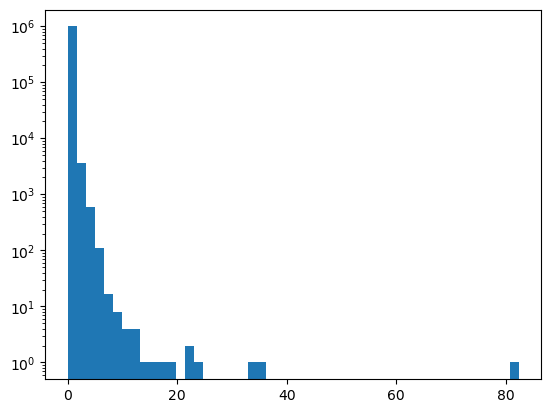

In [101]:
plt.hist(img.reshape(-1),bins = 50)
plt.semilogy()
(np.quantile(data,q = 0.95),max(data_res))
np.min(img[img!=0])

Leap081_12


'\nbackground = restoration.rolling_ball(img_float,radius = 50,num_threads = 10)\nplt.figure()\nplt.imshow(skimage.exposure.equalize_hist(img_float-background))\nplt.colorbar()\n'

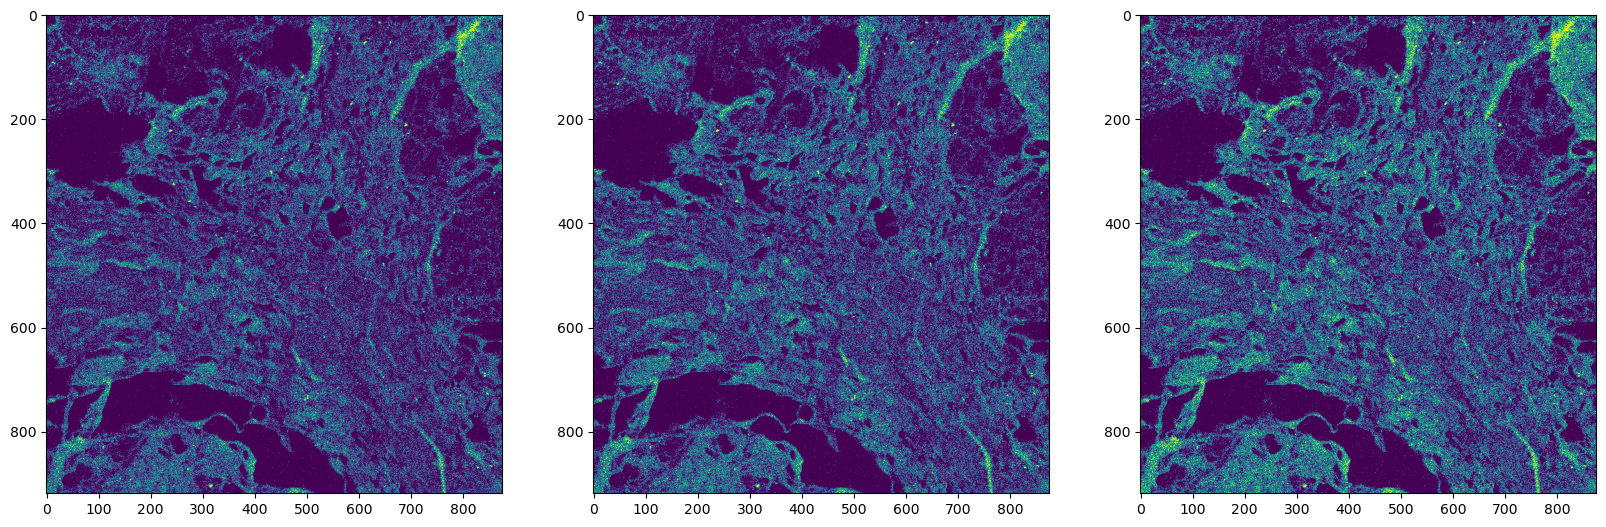

In [36]:
f,axs = plt.subplots(nrows=1,ncols=3,figsize = (20,20))
ind = 61
img = img_res[ind]
print(file_list[file_list['SAMPLE_TYPE_(CORE/RESECTION)']=='RESECTION'].acquisition_ID.iloc[ind])
img_float = skimage.exposure.rescale_intensity(img,in_range=(np.quantile(data,q = 0.95),max(data_res)))
axs[0].imshow(img_float,vmax = 1)
axs[1].imshow(skimage.exposure.equalize_adapthist(img_float),vmax = 1)
axs[2].imshow(skimage.exposure.equalize_hist(img_float),vmax = 1)

'''
background = restoration.rolling_ball(img_float,radius = 50,num_threads = 10)
plt.figure()
plt.imshow(skimage.exposure.equalize_hist(img_float-background))
plt.colorbar()
'''


In [33]:
np.stack((np.arange(len(data_res)),data_res)).T

array([[0.00000000e+00, 6.46240044e+00],
       [1.00000000e+00, 0.00000000e+00],
       [2.00000000e+00, 0.00000000e+00],
       [3.00000000e+00, 0.00000000e+00],
       [4.00000000e+00, 0.00000000e+00],
       [5.00000000e+00, 1.43341827e+00],
       [6.00000000e+00, 0.00000000e+00],
       [7.00000000e+00, 0.00000000e+00],
       [8.00000000e+00, 0.00000000e+00],
       [9.00000000e+00, 0.00000000e+00],
       [1.00000000e+01, 0.00000000e+00],
       [1.10000000e+01, 0.00000000e+00],
       [1.20000000e+01, 0.00000000e+00],
       [1.30000000e+01, 0.00000000e+00],
       [1.40000000e+01, 0.00000000e+00],
       [1.50000000e+01, 0.00000000e+00],
       [1.60000000e+01, 0.00000000e+00],
       [1.70000000e+01, 0.00000000e+00],
       [1.80000000e+01, 0.00000000e+00],
       [1.90000000e+01, 0.00000000e+00],
       [2.00000000e+01, 0.00000000e+00],
       [2.10000000e+01, 1.00000000e+00],
       [2.20000000e+01, 0.00000000e+00],
       [2.30000000e+01, 0.00000000e+00],
       [2.400000

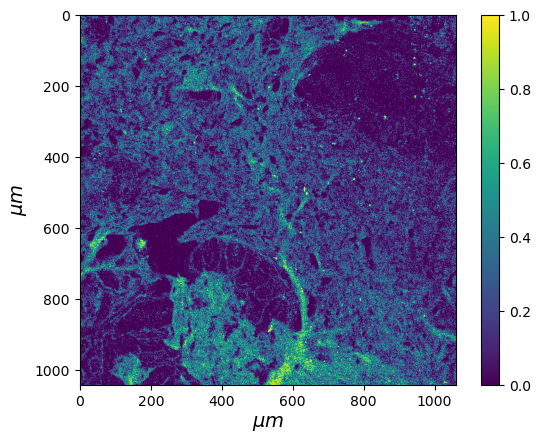

In [7]:
plt.imshow(skimage.exposure.rescale_intensity(skimage.exposure.equalize_hist(img_float)))
plt.colorbar()
plt.xlabel('$\\mu m$',fontsize = 14)
plt.ylabel('$\\mu m$',fontsize = 14)
#plt.savefig('Carboplatin.png')

In [163]:
file_list = glob.glob('/home/giuseppe/devices/Delta_Tissue/IMC/Img_Denoised/*/Carboplatin.tiff')
file_list = pd.DataFrame(file_list,columns = ['path'])
file_list['acquisition_ID'] = file_list.path.str.split('/').str[-2]
file_list['Leap_ID'] = file_list.acquisition_ID.str.split('_',n = 1).str[0].str.upper()
file_list['Leap_ID'] = file_list['Leap_ID'].str[:7]#leap_ID should be Leap123, anything more is stripped
biosamples_path = '~/devices/Delta_Tissue/IMC/IMC_data/ExtraDocs/processed_response.csv'
biosamples =pd.read_csv(biosamples_path)
file_list = file_list.merge(biosamples,left_on='Leap_ID',right_on= 'LEAP_ID').drop(['LEAP_ID'],axis = 1)#add metadata on patient
file_list.iloc[:10]

,path,acquisition_ID,Leap_ID,SLIDE_NUMBER,BIOBANK_ID,SAMPLE_TYPE_(CORE/RESECTION),FORMAT_(FFPE/FROZEN),FORCE_TRIAL?_(Y/N),DATE_SECTIONED,H&E_NOTES,ST_NOTES,Response,COMMENTS
0,/home/giuseppe/devices/Delta_Tissue/IMC/Img_De...,Leap081_8,LEAP081,35.0,18000527-IncT FPE-2,RESECTION,FFPE,NaN,2023-02-06 00:00:00,NaN,NaN,Non-Responder,RESECTION
1,/home/giuseppe/devices/Delta_Tissue/IMC/Img_De...,Leap081_1,LEAP081,35.0,18000527-IncT FPE-2,RESECTION,FFPE,NaN,2023-02-06 00:00:00,NaN,NaN,Non-Responder,RESECTION
2,/home/giuseppe/devices/Delta_Tissue/IMC/Img_De...,Leap081_12,LEAP081,35.0,18000527-IncT FPE-2,RESECTION,FFPE,NaN,2023-02-06 00:00:00,NaN,NaN,Non-Responder,RESECTION
3,/home/giuseppe/devices/Delta_Tissue/IMC/Img_De...,Leap081_3,LEAP081,35.0,18000527-IncT FPE-2,RESECTION,FFPE,NaN,2023-02-06 00:00:00,NaN,NaN,Non-Responder,RESECTION
4,/home/giuseppe/devices/Delta_Tissue/IMC/Img_De...,Leap081_6,LEAP081,35.0,18000527-IncT FPE-2,RESECTION,FFPE,NaN,2023-02-06 00:00:00,NaN,NaN,Non-Responder,RESECTION
5,/home/giuseppe/devices/Delta_Tissue/IMC/Img_De...,Leap081_4,LEAP081,35.0,18000527-IncT FPE-2,RESECTION,FFPE,NaN,2023-02-06 00:00:00,NaN,NaN,Non-Responder,RESECTION
6,/home/giuseppe/devices/Delta_Tissue/IMC/Img_De...,Leap081_7,LEAP081,35.0,18000527-IncT FPE-2,RESECTION,FFPE,NaN,2023-02-06 00:00:00,NaN,NaN,Non-Responder,RESECTION
7,/home/giuseppe/devices/Delta_Tissue/IMC/Img_De...,Leap081_10,LEAP081,35.0,18000527-IncT FPE-2,RESECTION,FFPE,NaN,2023-02-06 00:00:00,NaN,NaN,Non-Responder,RESECTION
8,/home/giuseppe/devices/Delta_Tissue/IMC/Img_De...,Leap081_9,LEAP081,35.0,18000527-IncT FPE-2,RESECTION,FFPE,NaN,2023-02-06 00:00:00,NaN,NaN,Non-Responder,RESECTION
9,/home/giuseppe/devices/Delta_Tissue/IMC/Img_De...,Leap081_11,LEAP081,35.0,18000527-IncT FPE-2,RESECTION,FFPE,NaN,2023-02-06 00:00:00,NaN,NaN,Non-Responder,RESECTION


In [76]:
for file in file_list[file_list['SAMPLE_TYPE_(CORE/RESECTION)']=='RESECTION'].path:
    #load the distribution of the image
    img = skimage.io.imread(file)
    break

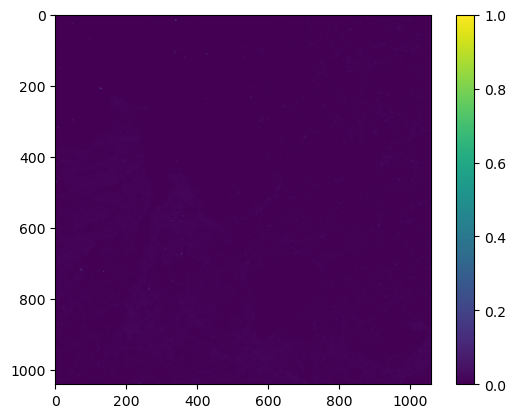

In [79]:
plt.imshow(skimage.exposure.rescale_intensity(img))
plt.colorbar()

(array([181.,  12.,   4.,   4.,   4.,   0.,   0.,   2.,   0.,   2.]),
 array([   5.81638861,  157.8323822 ,  309.84838867,  461.86437988,
         613.88037109,  765.8963623 ,  917.91235352, 1069.92834473,
        1221.94433594, 1373.96032715, 1525.97631836]),
 <BarContainer object of 10 artists>)

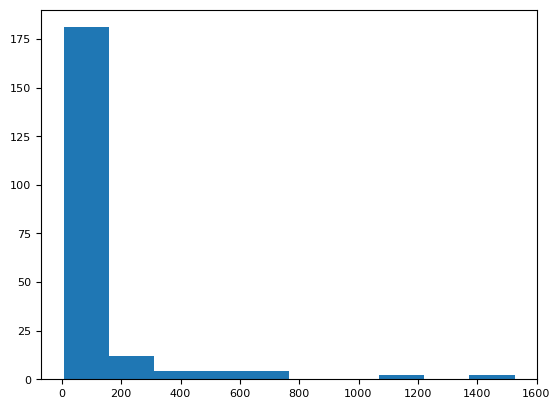

In [120]:
plt.hist([np.max(img) for img in img_list])

In [106]:
cell_table = pd.read_csv('../../segmentation/cell_table_Denoised/cell_table_size_normalized_cell_labels.csv',usecols=None)

In [25]:
import scanpy as sc
adata = sc.read_h5ad('../../IMC_analysis/phenotyping/pixie/data/sc_protein.h5ad')

In [18]:
adata.obs

,acquisition_ID,Leap_ID,SLIDE_NUMBER,BIOBANK_ID,SAMPLE_TYPE_(CORE/RESECTION),FORMAT_(FFPE/FROZEN),FORCE_TRIAL?_(Y/N),DATE_SECTIONED,H&E_NOTES,ST_NOTES,Response,COMMENTS,note_if_frozen_(otherwise_FFPE),Extreme_non-responder_(death_within_2_years?),qc_pass
index,,,,,,,,,,,,,,,
0,Leap001_10,LEAP001,1.0,19005858-FPE US (C)-1-FPEDiv-1,CORE,FFPE,NaN,21/06/2022,NaN,NaN,Non-Responder,core,NaN,NaN,False
1,Leap001_10,LEAP001,1.0,19005858-FPE US (C)-1-FPEDiv-1,CORE,FFPE,NaN,21/06/2022,NaN,NaN,Non-Responder,core,NaN,NaN,False
2,Leap001_10,LEAP001,1.0,19005858-FPE US (C)-1-FPEDiv-1,CORE,FFPE,NaN,21/06/2022,NaN,NaN,Non-Responder,core,NaN,NaN,True
3,Leap001_10,LEAP001,1.0,19005858-FPE US (C)-1-FPEDiv-1,CORE,FFPE,NaN,21/06/2022,NaN,NaN,Non-Responder,core,NaN,NaN,False
4,Leap001_10,LEAP001,1.0,19005858-FPE US (C)-1-FPEDiv-1,CORE,FFPE,NaN,21/06/2022,NaN,NaN,Non-Responder,core,NaN,NaN,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3964191,Leap096_9,LEAP096,41.0,17033511-IncT FPE-1,RESECTION,FFPE,NaN,2023-03-13 00:00:00,NaN,NaN,Non-Responder,resection,NaN,NaN,True
3964192,Leap096_9,LEAP096,41.0,17033511-IncT FPE-1,RESECTION,FFPE,NaN,2023-03-13 00:00:00,NaN,NaN,Non-Responder,resection,NaN,NaN,True
3964193,Leap096_9,LEAP096,41.0,17033511-IncT FPE-1,RESECTION,FFPE,NaN,2023-03-13 00:00:00,NaN,NaN,Non-Responder,resection,NaN,NaN,True


In [85]:
new_files = ['Leap004_11', 'Leap004_12', 'Leap004_13', 'Leap003_14', 'Leap003_15', 'Leap003_16', 'Leap010_6', 'Leap010_8', 'Leap010_9', 'Leap010_10', 'Leap010_11', 'Leap010_12', 'Leap010_13', 'Leap011_1', 'Leap011_2', 'Leap011_3', 'Leap011_4', 'Leap011_5']
cond = adata.obs.acquisition_ID.isin(new_files)

#cond2 = adata[cond].obs['SAMPLE_TYPE_(CORE/RESECTION)'] == 'CORE'
#plt.hist(adata[cond][cond2,adata.var.index == 'Carboplatin'].X)
a = adata.obs[['acquisition_ID','SAMPLE_TYPE_(CORE/RESECTION)']].drop_duplicates()
a = a[a.acquisition_ID.isin(new_files)]
ids_core = a[a['SAMPLE_TYPE_(CORE/RESECTION)']=='CORE'].acquisition_ID
ids_res = a[a['SAMPLE_TYPE_(CORE/RESECTION)']=='RESECTION'].acquisition_ID
ids_res

index
50068    Leap004_11
53884    Leap004_12
57608    Leap004_13
Name: acquisition_ID, dtype: category
Categories (652, object): ['Leap001_8', 'Leap001_9', 'Leap001_10', 'Leap002_1', ..., 'Leap105_6', 'Leap105_7', 'Leap105_8', 'Leap105_9']

In [76]:
files_2_rename = {'Leap003_11': 'Leap004_11',
 'Leap003_12': 'Leap004_12',
 'Leap003_13': 'Leap004_13',
 'Leap004_14': 'Leap003_14',
 'Leap004_15': 'Leap003_15',
 'Leap004_16': 'Leap003_16',
 'Leap011_6': 'Leap010_6',
 'Leap011_8': 'Leap010_8',
 'Leap011_9': 'Leap010_9',
 'Leap011_10': 'Leap010_10',
 'Leap011_11': 'Leap010_11',
 'Leap011_12': 'Leap010_12',
 'Leap011_13': 'Leap010_13',
 'Leap010_1': 'Leap011_1',
 'Leap010_2': 'Leap011_2',
 'Leap010_3': 'Leap011_3',
 'Leap010_4': 'Leap011_4',
 'Leap010_5': 'Leap011_5'}



In [101]:
for file_old,file_new in files_2_rename.items():
    if file_new not in set(ids_res):
        continue

    img = skimage.io.imread('/home/giuseppe/devices/Delta_Tissue/IMC/split_channels_nohpf/'+file_old+'/Carboplatin.tiff')    
    img_float = skimage.exposure.rescale_intensity(img,in_range=(np.quantile(data,q = 0.95),max_data_res))
    if q>1.2:
        #if the image has a lot of signal, make it sharper
        img = skimage.exposure.rescale_intensity(skimage.exposure.equalize_hist(img_float))
    else:
        # in this case, exposure.equalize_hist tends to overcorrect dark region overamplifying noise. Use a more noise 
        img = skimage.exposure.rescale_intensity(skimage.exposure.equalize_adapthist(img_float))
    #output_file = '/home/giuseppe/devices/Delta_Tissue/IMC/Img_Denoised/'+file_new+'/Carboplatin.tiff'
    tp.imwrite(output_file,img)

thr = np.quantile(data_res,q = 0.95)

In [103]:
list(ids_res)

['Leap004_11', 'Leap004_12', 'Leap004_13']

(array([2934968.,   89491.,   76650.,   64909.,   53800.,   45072.,
          36893.,   30500.,   25491.,  199086.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

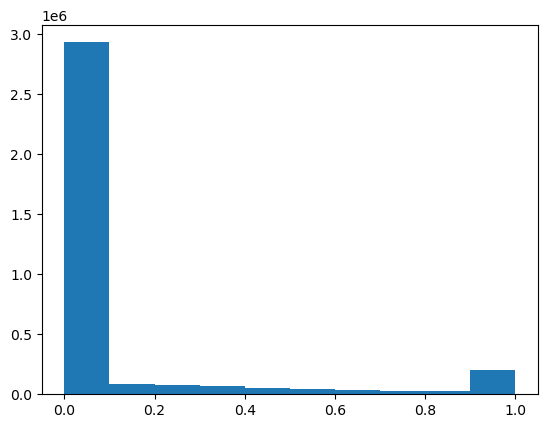

In [104]:
plt.hist(adata[:,adata.var.index == 'Carboplatin'].X)

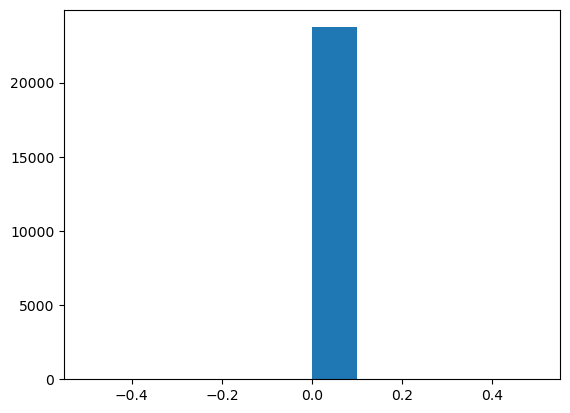

In [116]:
plt.hist(cell_table[cell_table.fov.isin(ids_core)].Carboplatin)
cell_table.loc[cell_table.fov.isin(ids_core),'Carboplatin'] = 0

In [122]:
cell_table[cell_table.fov.isin(set(ids_res))].Carboplatin

50068   NaN
50069   NaN
50070   NaN
50071   NaN
50072   NaN
         ..
62584   NaN
62585   NaN
62586   NaN
62587   NaN
62588   NaN
Name: Carboplatin, Length: 12521, dtype: float64

In [120]:
set(ids_res)

{'Leap004_11', 'Leap004_12', 'Leap004_13'}